In [5]:
# Setup: essential libraries (clean dev/test env, no Kaggle paths needed)
import numpy as np        # linear algebra
import pandas as pd       # data processing (CSV file I/O)
import matplotlib.pyplot as plt
# works in Jupyter; harmless if run as a plain script
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass


In [6]:
import os

# locate the dataset no matter which directory the notebook is run from
candidates = ["../data/Salary_dataset.csv", "data/Salary_dataset.csv", "../../data/Salary_dataset.csv"]
file_path = next((p for p in candidates if os.path.exists(p)), None)
if file_path is None:
    raise FileNotFoundError("Could not find Salary_dataset.csv. Update 'candidates' with the correct path.")

Data = pd.read_csv(file_path)
Data


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0
5,5,3.0,56643.0
6,6,3.1,60151.0
7,7,3.3,54446.0
8,8,3.3,64446.0
9,9,3.8,57190.0


In [7]:
Data.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [8]:
Data.tail()

,Unnamed: 0,YearsExperience,Salary
25,25,9.1,105583.0
26,26,9.6,116970.0
27,27,9.7,112636.0
28,28,10.4,122392.0
29,29,10.6,121873.0


In [9]:
Data.describe()

,Unnamed: 0,YearsExperience,Salary
count,30.000000,30.000000,30.000000
mean,14.500000,5.413333,76004.000000
std,8.803408,2.837888,27414.429785
min,0.000000,1.200000,37732.000000
25%,7.250000,3.300000,56721.750000
50%,14.500000,4.800000,65238.000000
75%,21.750000,7.800000,100545.750000
max,29.000000,10.600000,122392.000000


In [10]:
Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [11]:
Data.isna().sum()

Unnamed: 0         0
YearsExperience    0
Salary             0
dtype: int64

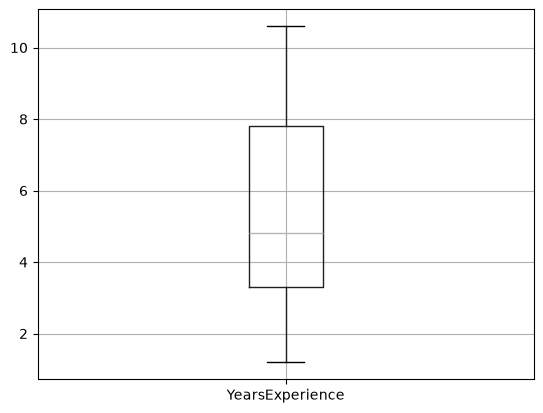

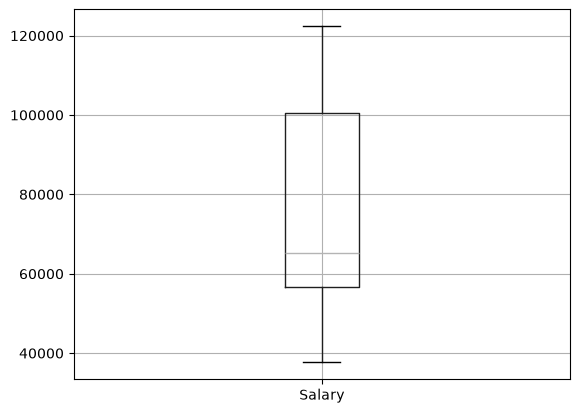

In [12]:
Data.boxplot(column=["YearsExperience"])
plt.show()

Data.boxplot(column=["Salary"])
plt.show()

In [13]:
Chosen_Data = Data[["YearsExperience", "Salary"]]

Chosen_Data.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


In [14]:
Chosen_Data.tail()

,YearsExperience,Salary
25,9.1,105583.0
26,9.6,116970.0
27,9.7,112636.0
28,10.4,122392.0
29,10.6,121873.0


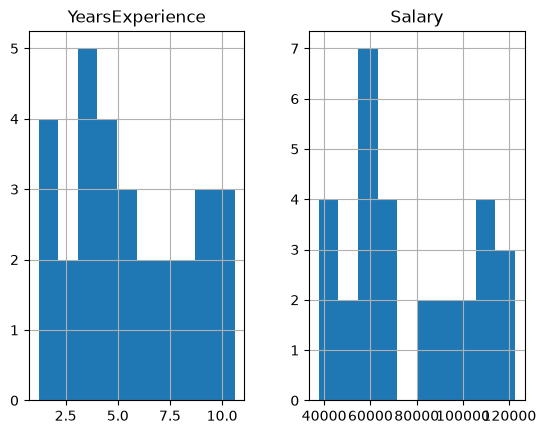

In [15]:
Histogram = Data[["YearsExperience", "Salary"]]

Histogram.hist()
plt.show()

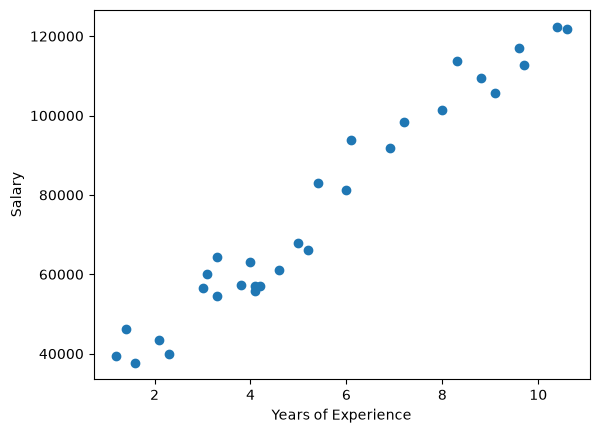

In [16]:
plt.scatter(Chosen_Data.YearsExperience, Chosen_Data.Salary)
plt.xlabel("Years of Experience")
plt.ylabel("Salary")
plt.show()

In [17]:
mask = np.random.rand(len(Chosen_Data)) < 0.8
print(mask)
train = Chosen_Data[mask]
test = Chosen_Data[~mask]

train.shape
#in the mask the random number is added after the ageexp and the salary over come overfiiting of the given data.#
#< 0.8: Converts those random decimals into True or False and on the basis of it select the data to choose for what train and test so it is toataly random

[ True  True False False  True  True False  True  True  True False  True
 False  True  True  True  True  True False  True False  True False  True
  True  True  True False  True  True]


(21, 2)

In [18]:
train.describe()
#here the describe tell us that the info about the not null and the other is about the x,del,and other info aboyt the data

,YearsExperience,Salary
count,21.000000,21.000000
mean,5.566667,77690.095238
std,2.922727,28442.858088
min,1.200000,39344.000000
25%,3.300000,56643.000000
50%,5.000000,66030.000000
75%,8.300000,105583.000000
max,10.600000,122392.000000


In [19]:
test.describe()

,YearsExperience,Salary
count,9.000000,9.000000
mean,5.055556,72069.777778
std,2.762748,26019.344072
min,1.600000,37732.000000
25%,3.100000,56958.000000
50%,4.100000,63219.000000
75%,6.900000,91739.000000
max,9.700000,112636.000000


In [20]:
from sklearn import linear_model

model = linear_model.LinearRegression()

train_x = np.asarray(train[["YearsExperience"]])
train_y = np.asarray(train[["Salary"]])

model.fit(train_x, train_y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[9478.30179108]]
Intercept: [24927.54860108]


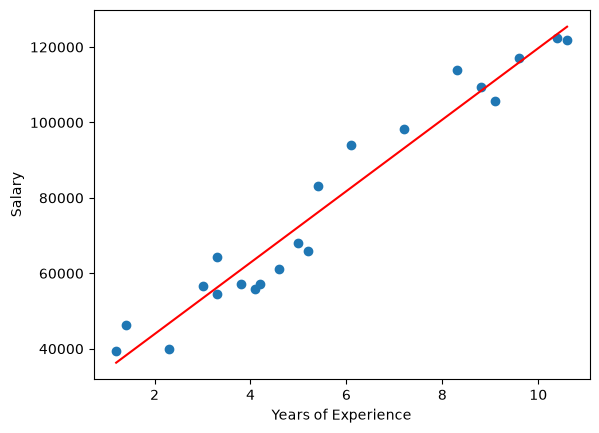

In [21]:
plt.scatter(train.YearsExperience, train.Salary)

plt.plot(
    train_x,
    model.coef_[0][0] * train_x + model.intercept_[0],
    '-r'
)

plt.xlabel("Years of Experience")
plt.ylabel("Salary")

plt.show()

In [22]:
from sklearn.metrics import r2_score

test_x = np.asarray(test[["YearsExperience"]])
test_y = np.asarray(test[["Salary"]])

test_y_ = model.predict(test_x)

print("Mean absolute error: %.2f" %
      np.mean(np.absolute(test_y_ - test_y)))

print("Residual sum of squares (MSE): %.2f" %
      np.mean((test_y_ - test_y) ** 2))

print("R2-score: %.2f" %
      r2_score(test_y, test_y_))

Mean absolute error: 2593.44
Residual sum of squares (MSE): 12063965.98
R2-score: 0.98
